<a href="https://colab.research.google.com/github/CristianRiascos/Alura-TelecomX-Parte2-Challenge/blob/master/Challenge3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# **Preparación de los Datos**

## Extracción del archivo tratado

In [2]:
data = pd.read_csv( 'datos_tratados.csv' )

## Eliminación de Columnas Irrelevantes

In [3]:
data.head(4)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Charges.Daily
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,Un Año,Yes,Cheque por Correo,65.6,593.30,2.19
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Mes a Mes,No,Cheque por Correo,59.9,542.40,2.00
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fibra Óptica,...,Yes,No,No,No,Mes a Mes,Yes,Cheque Electrónico,73.9,280.85,2.46
3,0011-IGKFF,Yes,Male,Sí,Yes,No,13,Yes,No,Fibra Óptica,...,Yes,No,Yes,Yes,Mes a Mes,Yes,Cheque Electrónico,98.0,1237.85,3.27


In [4]:
data.drop( columns=['customerID'], inplace=True )

## Enconde

In [5]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [6]:
# Seleccionar las columnas categóricas
categorical_columns = data.select_dtypes(exclude=['int64', 'float64']).columns
categorical_columns

Index(['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [7]:
# Crear transformador
transformer = make_column_transformer(
    ( OneHotEncoder(drop='first'), categorical_columns ),
    remainder='passthrough',
    sparse_threshold=0,
    force_int_remainder_cols=False
)

In [8]:
# Crear DataFrame
X_transformed = transformer.fit_transform(data)
encoded_df = pd.DataFrame(
    X_transformed,
    columns=transformer.get_feature_names_out()
)
encoded_df.head(4)

,onehotencoder__Churn_Yes,onehotencoder__gender_Male,onehotencoder__SeniorCitizen_Sí,onehotencoder__Partner_Yes,onehotencoder__Dependents_Yes,onehotencoder__PhoneService_Yes,onehotencoder__MultipleLines_No phone service,onehotencoder__MultipleLines_Yes,onehotencoder__InternetService_Fibra Óptica,onehotencoder__InternetService_No,...,onehotencoder__Contract_Mes a Mes,onehotencoder__Contract_Un Año,onehotencoder__PaperlessBilling_Yes,onehotencoder__PaymentMethod_Cheque por Correo,onehotencoder__PaymentMethod_Tarjeta de Crédito (Automático),onehotencoder__PaymentMethod_Transferencia Bancaria (Automático),remainder__tenure,remainder__Charges.Monthly,remainder__Charges.Total,remainder__Charges.Daily
0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,0.0,0.0,9.0,65.6,593.30,2.19
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,9.0,59.9,542.40,2.00
2,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,4.0,73.9,280.85,2.46
3,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,13.0,98.0,1237.85,3.27


## Balanceo de la variable Churn

In [9]:
import matplotlib.pyplot as plt

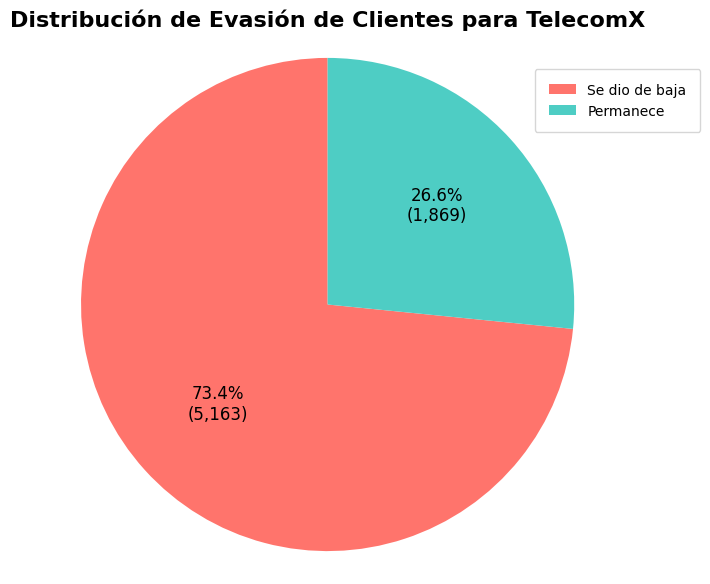

In [10]:
# Obtener el conteo de datos de la variable Churn
evasion = data['Churn'].value_counts()
total = sum(evasion.values)

# Cambiar a etiquetas más legibles para la leyenda
evasion.index = evasion.index.map({
    'Yes': 'Permanece',
    'No': 'Se dio de baja'
})

# Realizar el gráfico
plt.figure(figsize=(7, 7))
plt.pie( evasion.values,
         autopct=lambda pct: f'{pct:.1f}%\n({int(round(pct * total / 100.0)):,})',
         textprops={'fontsize': 12},
         startangle=90,
         colors=['#FF746C', '#4ecdc4']
         )

# Modificar título y leyenda
plt.title( 'Distribución de Evasión de Clientes para TelecomX', fontsize=16, fontweight='bold' )
plt.axis('equal')
plt.legend( evasion.index,  loc='upper right', bbox_to_anchor=(1.20, 0.95), borderpad=1.0 )
plt.show()

# **Correlación y Selección de Variable**s

## Análisis de Correlación

In [11]:
import seaborn as sns
import numpy as np
import plotly.graph_objects as go

In [12]:
correlation = encoded_df.corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))
correlation_masked = correlation.copy()
correlation_masked[mask] = np.nan

fig = go.Figure(data=go.Heatmap(
    z=correlation_masked.values,
    x=correlation_masked.columns,
    y=correlation_masked.index,
    colorscale='RdBu_r',
    zmid=0,
    colorbar=dict(title="Correlación"),
    hovertemplate='<b>%{y}</b> vs <b>%{x}</b><br>Correlación: <b>%{z:.3f}</b><extra></extra>'
))

fig.update_layout(
    title={
        'text': 'Mapa de Correlación de Variables',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 18, 'weight': 'bold'}
    },
    width=1000,
    height=900,
    xaxis=dict(
        tickangle=-45,
        tickfont=dict(size=9)
    ),
    yaxis=dict(
        autorange='reversed',
        tickfont=dict(size=9)
    )
)

fig.show()

## Relación de variables respecto a la cancelación (Churn)

In [13]:
churn_corr = encoded_df.corr()['onehotencoder__Churn_Yes'].drop('onehotencoder__Churn_Yes').sort_values()

fig = go.Figure(go.Bar(
    x=churn_corr.values,
    y=churn_corr.index,
    orientation='h',
    marker=dict(
        color=churn_corr.values,
        colorscale='RdBu_r',
        cmid=0,
        colorbar=dict(title="Correlación")
    ),
    hovertemplate='<b>%{y}</b><br>Correlación: <b>%{x:.3f}</b><extra></extra>'
))

fig.update_layout(
    title={
        'text': 'Correlación de Variables respecto a Churn',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 18, 'weight': 'bold'}
    },
    width=900,
    height=900,
    xaxis=dict(title='Correlación', zeroline=True, zerolinewidth=2, zerolinecolor='black'),
    yaxis=dict(tickfont=dict(size=9)),
    bargap=0.2
)

fig.show()

# **Modelado Predictivo**

## Separación de datos

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
y = encoded_df['onehotencoder__Churn_Yes']
X = encoded_df.drop(columns=['onehotencoder__Churn_Yes'])

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3, # 70/30
    stratify=y,
    random_state=42
)

## Selección de variables

In [17]:
import pandas as pd

# Correlación de todas las variables respecto a Churn
importances = encoded_df.corr()['onehotencoder__Churn_Yes'].abs()
importances = importances.drop('onehotencoder__Churn_Yes').sort_values(ascending=False)

top_10 = importances.head(10).index.tolist()
top_15 = importances.head(15).index.tolist()

print("TOP 10 VARIABLES:")
print(importances.head(10).to_string())
print("\nTOP 15 VARIABLES:")
print(importances.head(15).to_string())

TOP 10 VARIABLES:
onehotencoder__Contract_Mes a Mes                      0.404565
remainder__tenure                                      0.354049
onehotencoder__InternetService_Fibra Óptica            0.307463
onehotencoder__OnlineBackup_No internet service        0.227578
onehotencoder__DeviceProtection_No internet service    0.227578
onehotencoder__InternetService_No                      0.227578
onehotencoder__OnlineSecurity_No internet service      0.227578
onehotencoder__TechSupport_No internet service         0.227578
onehotencoder__StreamingMovies_No internet service     0.227578
onehotencoder__StreamingTV_No internet service         0.227578

TOP 15 VARIABLES:
onehotencoder__Contract_Mes a Mes                      0.404565
remainder__tenure                                      0.354049
onehotencoder__InternetService_Fibra Óptica            0.307463
onehotencoder__OnlineBackup_No internet service        0.227578
onehotencoder__DeviceProtection_No internet service    0.227578
one

## Balanceo de Clases (Oversampling)

In [18]:
from imblearn.over_sampling import SMOTE

In [19]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

## Creación de Modelos

### Regresión Logística

Normalización de datos

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled  = scaler.transform(X_test)

Tunning

In [22]:
from sklearn.linear_model import LogisticRegression

In [23]:
lr_params = {
    'C':       [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver':  ['saga']
}

scalers = {}

for name, features in [('10', top_10), ('15', top_15), ('all', X_train_sm.columns.tolist())]:
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_train_sm[features])
    scalers[name] = scaler                          # guardar para transformar X_test después

    lr_grid = GridSearchCV(
        LogisticRegression(max_iter=5000, class_weight='balanced', random_state=42),
        lr_params, cv=5, scoring='f1', n_jobs=-1
    )
    lr_grid.fit(X_tr_scaled, y_train_sm)
    print(f"Mejores params LR ({name}):", lr_grid.best_params_)
    if   name == '10':  lr_10  = lr_grid.best_estimator_
    elif name == '15':  lr_15  = lr_grid.best_estimator_
    else:               lr_all = lr_grid.best_estimator_

# X_test escalado por cada scaler correspondiente
X_test_scaled_10  = scalers['10'].transform(X_test[top_10])
X_test_scaled_15  = scalers['15'].transform(X_test[top_15])
X_test_scaled_all = scalers['all'].transform(X_test)

Mejores params LR (10): {'C': 0.01, 'penalty': 'l1', 'solver': 'saga'}
Mejores params LR (15): {'C': 0.1, 'penalty': 'l1', 'solver': 'saga'}
Mejores params LR (all): {'C': 1, 'penalty': 'l1', 'solver': 'saga'}


### Random Forest

In [24]:
from sklearn.ensemble import RandomForestClassifier

Tunning

In [25]:
rf_params = {
    'n_estimators':    [100, 200, 300],
    'max_depth':       [5, 10, 15, None],
    'min_samples_leaf':[2, 5, 10],
    'max_features':    ['sqrt', 'log2']
}

for name, features in [('10', top_10), ('15', top_15), ('all', X_train_sm.columns.tolist())]:
    rf_grid = GridSearchCV(
        RandomForestClassifier(class_weight='balanced', random_state=42),
        rf_params, cv=5, scoring='f1', n_jobs=-1
    )
    rf_grid.fit(X_train_sm[features], y_train_sm)
    print(f"Mejores params RF ({name}):", rf_grid.best_params_)
    if   name == '10':  rf_10  = rf_grid.best_estimator_
    elif name == '15':  rf_15  = rf_grid.best_estimator_
    else:               rf_all = rf_grid.best_estimator_

Mejores params RF (10): {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 100}
Mejores params RF (15): {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 300}
Mejores params RF (all): {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 300}


## Evaluación de Modelos

**Función para evaluar modelos**

In [26]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)

In [27]:
def evaluar_modelo(nombre, model, X_test, y_test):
    y_pred = model.predict(X_test)
    print(f"{'═'*50}")
    print(f"{nombre}")
    print(f"{'═'*50}")
    print(f"Exactitud:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precisión:  {precision_score(y_test, y_pred):.4f}")
    print(f"Recall:     {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score:   {f1_score(y_test, y_pred):.4f}")

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap='Blues')
    plt.title(nombre)
    plt.show()

### Regresión Logística

Usando las mejores 10 variables

══════════════════════════════════════════════════
LR Top 10
══════════════════════════════════════════════════
Exactitud:  0.7190
Precisión:  0.4826
Recall:     0.7914
F1-Score:   0.5996


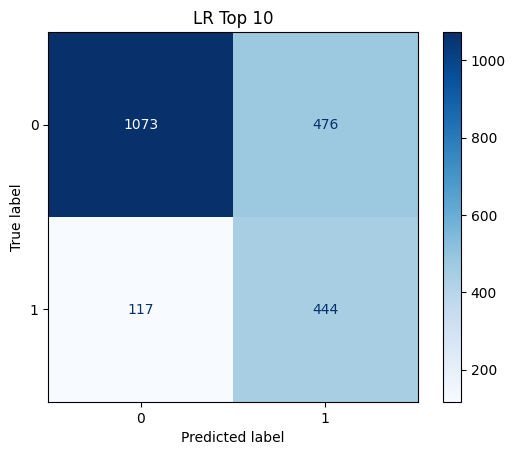

In [28]:
evaluar_modelo("LR Top 10", lr_10, X_test_scaled_10, y_test)

Usando las mejores 15 variables

══════════════════════════════════════════════════
LR Top 15
══════════════════════════════════════════════════
Exactitud:  0.7232
Precisión:  0.4876
Recall:     0.8057
F1-Score:   0.6075


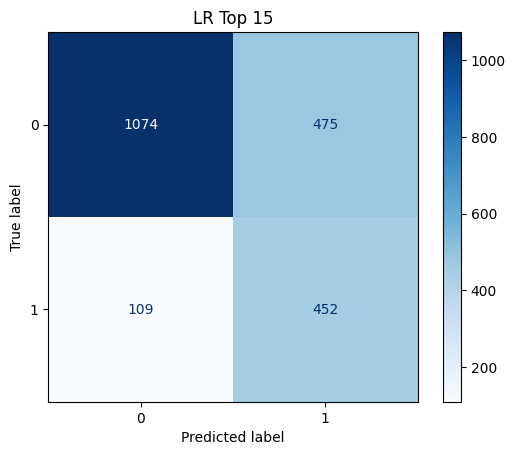

In [29]:
evaluar_modelo("LR Top 15", lr_15, X_test_scaled_15, y_test)

Usando todas las variables

══════════════════════════════════════════════════
LR All
══════════════════════════════════════════════════
Exactitud:  0.7464
Precisión:  0.5149
Recall:     0.8004
F1-Score:   0.6267


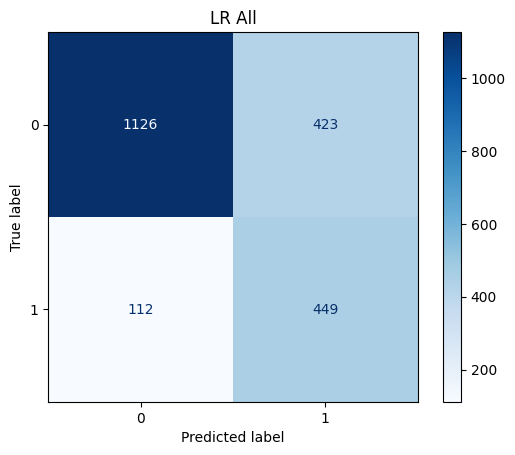

In [30]:
evaluar_modelo("LR All", lr_all, X_test_scaled_all, y_test)

### Random Forest

Top 10

══════════════════════════════════════════════════
Random Forest Top 10
══════════════════════════════════════════════════
Exactitud:  0.7635
Precisión:  0.5401
Recall:     0.7451
F1-Score:   0.6262


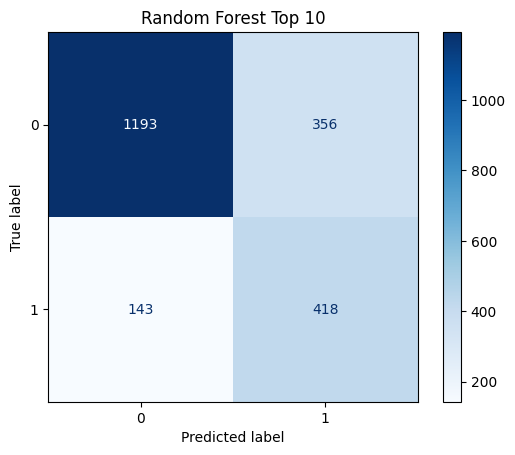

In [31]:
evaluar_modelo("Random Forest Top 10",  rf_10,  X_test[top_10], y_test)

Usando las mejores 15 variables

══════════════════════════════════════════════════
Random Forest Top 15
══════════════════════════════════════════════════
Exactitud:  0.7711
Precisión:  0.5582
Recall:     0.6667
F1-Score:   0.6076


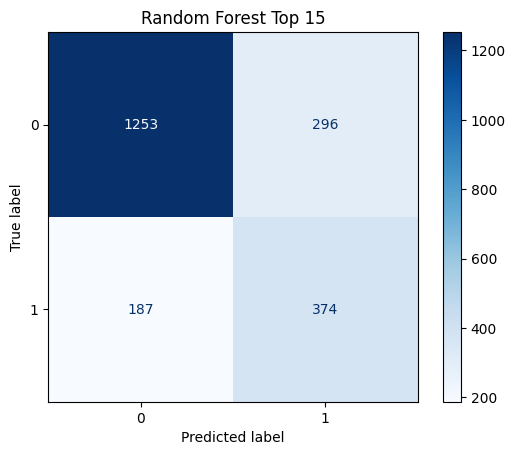

In [32]:
evaluar_modelo("Random Forest Top 15", rf_15, X_test[top_15], y_test)

Usando todas las variables

══════════════════════════════════════════════════
RANDOM FOREST All
══════════════════════════════════════════════════
Exactitud:  0.7735
Precisión:  0.5651
Recall:     0.6417
F1-Score:   0.6010


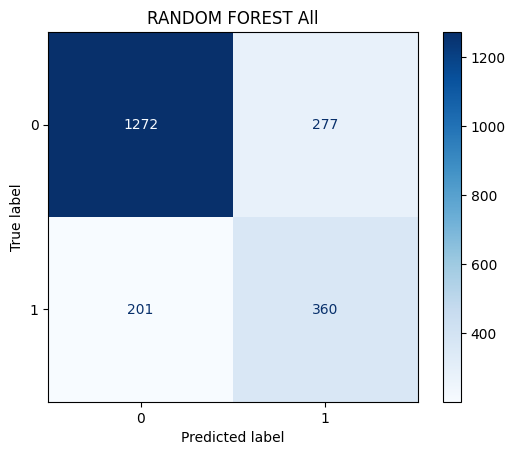

In [33]:
evaluar_modelo("RANDOM FOREST All", rf_all, X_test[X_train_sm.columns.tolist()], y_test)

## Comparación de Modelos

Función para comparar

In [34]:
def metricas(nombre, model, X_te, y_te):
    y_pred = model.predict(X_te)
    return {
        'Modelo':     nombre,
        'Exactitud':  accuracy_score(y_te, y_pred),
        'Precisión':  precision_score(y_te, y_pred),
        'Recall':     recall_score(y_te, y_pred),
        'F1-Score':   f1_score(y_te, y_pred)
    }

Mejor modelo de Regresión Logística

In [35]:
resultados_lr = pd.DataFrame([
    metricas('LR Top 10',  lr_10,  X_test_scaled_10,  y_test),
    metricas('LR Top 15',  lr_15,  X_test_scaled_15,  y_test),
    metricas('LR All',     lr_all, X_test_scaled_all, y_test)
]).set_index('Modelo').round(4)

print(resultados_lr)
mejor_lr_nombre = resultados_lr['F1-Score'].idxmax()
print(f"\nMejor Regresión Logística: {mejor_lr_nombre}")

           Exactitud  Precisión  Recall  F1-Score
Modelo                                           
LR Top 10     0.7190     0.4826  0.7914    0.5996
LR Top 15     0.7232     0.4876  0.8057    0.6075
LR All        0.7464     0.5149  0.8004    0.6267

Mejor Regresión Logística: LR All


Mejor modelo de Random Forest

In [36]:
resultados_rf = pd.DataFrame([
    metricas('RF Top 10',  rf_10,  X_test[top_10],                     y_test),
    metricas('RF Top 15',  rf_15,  X_test[top_15],                     y_test),
    metricas('RF All',     rf_all, X_test[X_train_sm.columns.tolist()], y_test)
]).set_index('Modelo').round(4)

print(resultados_rf)
mejor_rf_nombre = resultados_rf['F1-Score'].idxmax()
print(f"\nMejor Random Forest: {mejor_rf_nombre}")

           Exactitud  Precisión  Recall  F1-Score
Modelo                                           
RF Top 10     0.7635     0.5401  0.7451    0.6262
RF Top 15     0.7711     0.5582  0.6667    0.6076
RF All        0.7735     0.5651  0.6417    0.6010

Mejor Random Forest: RF Top 10


### Mejor Modelo en general

In [37]:
resultados_final = pd.DataFrame([
    metricas('LR All',     lr_all, X_test_scaled_all, y_test),
    metricas('RF Top 10',  rf_10,  X_test[top_10],    y_test)
]).set_index('Modelo').round(4)

print(resultados_final)

           Exactitud  Precisión  Recall  F1-Score
Modelo                                           
LR All        0.7464     0.5149  0.8004    0.6267
RF Top 10     0.7635     0.5401  0.7451    0.6262


El mejor model en general es el de Regresión Logística usando todas las variables (LR All)

# **Informe**

## **Introducción**

El presente documento tiene como objetivo principal la implementación de un modelo predictivo de clasificación binaria con la capacidad de determinar qué clientes tienen mayor probabilidad de cancelar sus servicios.

Dentro de este documento se puede encontrar todo el proceso que consistió en el tratamiento de datos, entrenamiento y evaluación de resultados de los modelos de clasificación, específicamente **Regresión Logística** y **Random Forest**

## **Desbalance de la Cancelación**

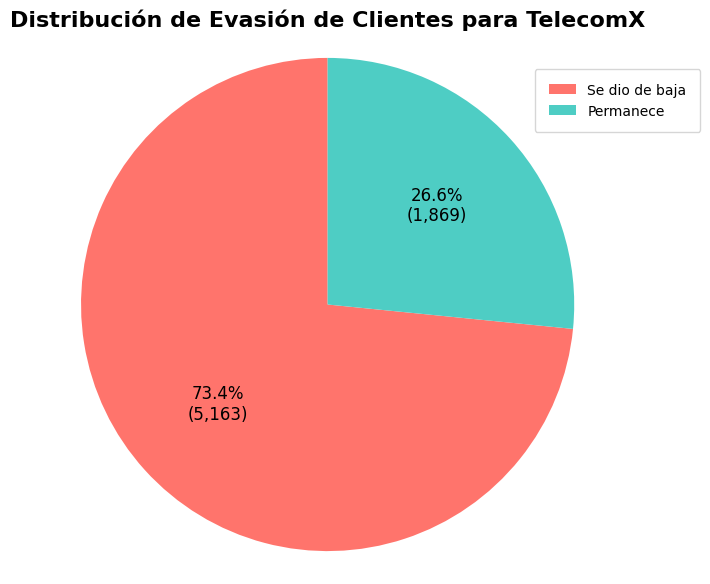

In [38]:
# Obtener el conteo de datos de la variable Churn
evasion = data['Churn'].value_counts()
total = sum(evasion.values)

# Cambiar a etiquetas más legibles para la leyenda
evasion.index = evasion.index.map({
    'Yes': 'Permanece',
    'No': 'Se dio de baja'
})

# Realizar el gráfico
plt.figure(figsize=(7, 7))
plt.pie( evasion.values,
         autopct=lambda pct: f'{pct:.1f}%\n({int(round(pct * total / 100.0)):,})',
         textprops={'fontsize': 12},
         startangle=90,
         colors=['#FF746C', '#4ecdc4']
         )

# Modificar título y leyenda
plt.title( 'Distribución de Evasión de Clientes para TelecomX', fontsize=16, fontweight='bold' )
plt.axis('equal')
plt.legend( evasion.index,  loc='upper right', bbox_to_anchor=(1.20, 0.95), borderpad=1.0 )
plt.show()

Una de las consideraciones iniciales es el desbalance considerable de los datos de cancelación como se puede apreciar en la imagen anterior.

Para solucionar esto se aplicó SMOTE (Synthetic Minority Oversampling Technique), una técnica de sobremuestreo que genera muestras sintéticas de la clase minoritaria (Permanece) hasta igualar la proporción con la clase mayoritaria (Se dio de baja). Esto evita que los modelos desarrollen un sesgo hacia predecir "Se dio de baja" por ser la clase dominante, garantizando un aprendizaje más equilibrado para ambas clases.


## **Selección de Variables**

El dataset cuenta con un total de 32 variables después del tratamiento de datos. Es decir, los modelos poseen con un máximo de 31 variables para usar.

Inicialmente estableció cuáles eran las 10 y 15 variables más importantes. Estas variables se obtuvieron mediante las correlaciones más fuertes entre una variable y Churn (cancelación). Considere que se usaron correlaciones tanto negativas como positivas.

Dicho de otra forma, estas son las variables que más peso tienen en determinar si un cliente abandona o no.

In [39]:
churn_corr_top15 = encoded_df.corr()['onehotencoder__Churn_Yes'][top_15].sort_values()

# Agregar rango al nombre de la variable
ranked_labels = [f"#{top_15.index(col) + 1} {col}" for col in churn_corr_top15.index]

fig = go.Figure(go.Bar(
    x=churn_corr_top15.values,
    y=ranked_labels,
    orientation='h',
    marker=dict(
        color=churn_corr_top15.values,
        colorscale='RdBu_r',
        cmid=0,
        colorbar=dict(title="Correlación")
    ),
    hovertemplate='<b>%{y}</b><br>Correlación: <b>%{x:.3f}</b><extra></extra>'
))

fig.update_layout(
    title={
        'text': 'Top 15 Variables con Mayor Correlación respecto a Churn',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 18, 'weight': 'bold'}
    },
    width=900, height=600,
    xaxis=dict(title='Correlación', zeroline=True, zerolinewidth=2, zerolinecolor='black'),
    yaxis=dict(tickfont=dict(size=10)),
    bargap=0.2
)

fig.show()

Después, usando esta selección se realizaron 3 versiones para cada modelo evaluado:


*   Una versión usa las 10 variables con mayor correlación
*   Otra versión usa las 15 variables con mayor correlación
*   La última versión usa todas las variables (31)


Para cada modelo se realizó una búsqueda de hiperparámetros mediante validación cruzada (GridSearchCV), probando todas las combinaciones posibles de los parámetros definidos. Por ejemplo, para cada variante de Regresión Logística (lr_10, lr_15, lr_all) se evaluaron distintos valroes de combinaciones de regularización y penalización, seleccionando la combinación que maximizó el F1-Score.



## **Criterios para elección de métricas de los modelos**

Si bien se aplicó SMOTE para balancear las clases durante el entrenamiento, el conjunto de prueba conserva la distribución real de los datos. Por ello, se utilizó el F1-Score como criterio de optimización, ya que pondera tanto la capacidad del modelo de detectar clientes en riesgo de cancelación (Recall) como la fiabilidad de esas predicciones (Precisión), siendo más representativo que la exactitud en escenarios con clases desiguales.

## **Mejor Modelo**

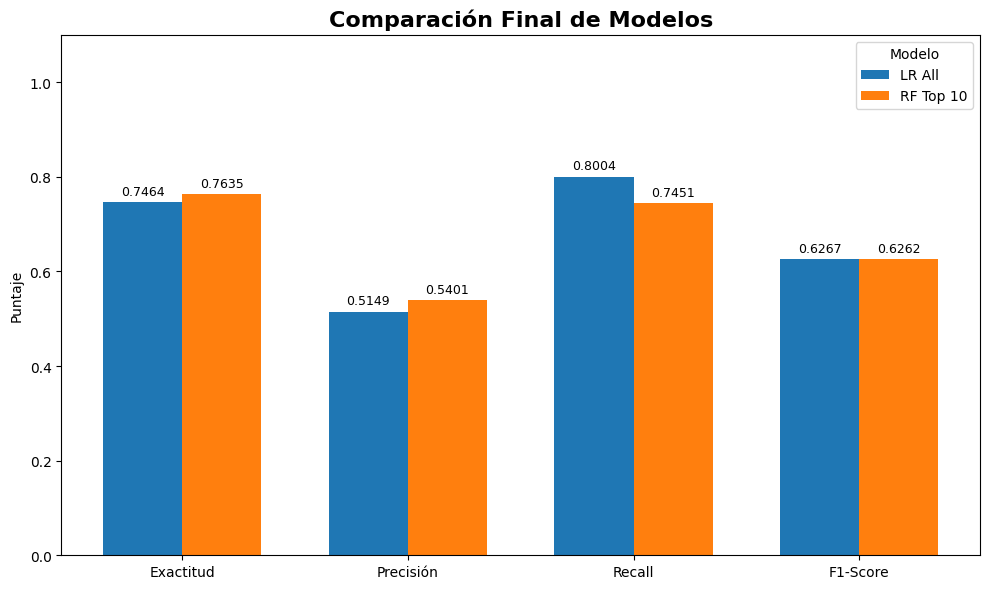

In [42]:
modelos  = resultados_final.index.tolist()
metricas = resultados_final.columns.tolist()
x        = np.arange(len(metricas))
ancho    = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

for i, modelo in enumerate(modelos):
    bars = ax.bar(x + i * ancho, resultados_final.loc[modelo], ancho, label=modelo)
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)

ax.set_title('Comparación Final de Modelos', fontsize=16, fontweight='bold')
ax.set_xticks(x + ancho / 2)
ax.set_xticklabels(metricas)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Puntaje')
ax.legend(title='Modelo')
plt.tight_layout()
plt.show()

Después de entrenar los modelos con los mejores hiperparámetros definidos para cada versión de Regresión Logística y Random Forest, se realizó la comparación para comprender cuál era la mejor versión de cada modelo; de esta forma, se obtuvo que eran Regresión Logística usando todas las variables (LR_ALL) y Random Forest usando las 10 más relevantes respecto a Churn (RF_10).

Ahora, al comparar los resultados de ambos modelos, se puede apreciar que la Exactitud y Precisión es superior en RF_10 que en LR_ALL, además cuentan con un F1-Score casi idéntico entre ambos. No obstante, **LR All es el mejor modelo** para este problema porque logra un Recall de 80% frente al 74.5% de RF, lo que significa que detecta más clientes en riesgo de cancelar.

El razonamiento consiste en que el costo de **no detectar a un cliente que se va (falso negativo) es mayor que el de actuar sobre uno que no iba a cancelar (falso positivo)**. Por eso el Recall tiene más peso estratégico que la Precisión o la Exactitud,

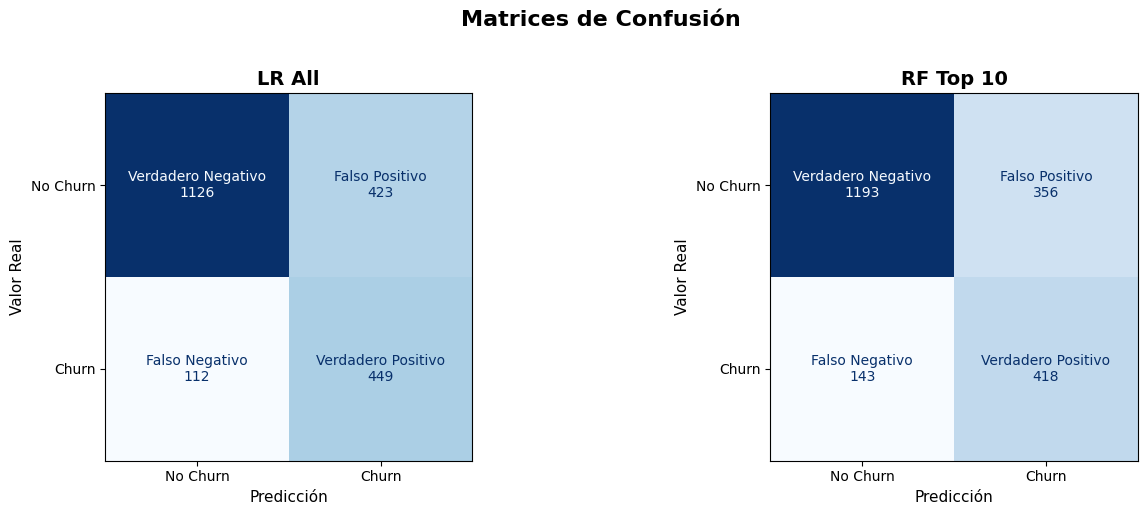

In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

modelos = {
    'LR All':    (lr_all, X_test_scaled_all),
    'RF Top 10': (rf_10,  X_test[top_10])
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (nombre, (modelo, X_te)) in zip(axes, modelos.items()):
    cm = confusion_matrix(y_test, modelo.predict(X_te))
    disp = ConfusionMatrixDisplay(
        cm,
        display_labels=['No Churn', 'Churn']
    )
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(nombre, fontsize=14, fontweight='bold')
    ax.set_xlabel('Predicción', fontsize=11)
    ax.set_ylabel('Valor Real', fontsize=11)

    # Anotar cada celda con su significado
    ax.texts[0].set_text(f"Verdadero Negativo\n{cm[0,0]}")
    ax.texts[1].set_text(f"Falso Positivo\n{cm[0,1]}")
    ax.texts[2].set_text(f"Falso Negativo\n{cm[1,0]}")
    ax.texts[3].set_text(f"Verdadero Positivo\n{cm[1,1]}")

plt.suptitle('Matrices de Confusión', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## **Factores que más influyen en la cancelación**

Retomando lo hablado en la sección de *Selección de Variables*, las siguientes son las características que afectan mayormente en la cancelación:


1.   **Contratos de Tipo Mes a Mes (0.40):** Al no tener compromiso, existe mayor facilidad para cancelar.

2.   **Internet Fibra Óptica(0.31):** Los clientes con fibra óptica tiene una mayor probabilidad de cancelar, puede deberse a expectativas no cumplidas.


Ahora, estos factores contribuyen a una reducción de probabilidad de que un cliente **no** cancele:


1.   **Antigüedad (-0.35):** Entre más tiempo como cliente, menor su probabilidad de cancelar.
2.   **Sin servicio de internet (-0.23):** Clientes sin servicio de internet contratado tienen menor tasa de cancelación.
3.   **Servicios adicionales (-0.23):** Servicios adicionales, específicamente Backup, Seguridad, Soporte y/o Streaming reduce la probabilidad de cancelar.





## **Estrategias de retención**

1. **Contratos de Tipo Mes a Mes:** Se recomienda frecer descuentos o beneficios exclusivos para migrar a contratos de 1 o 2 años.

2. **Internet Fibra Óptica:** Revisar la satisfacción del servicio de Internet de Fibra óptica, dependiendo de los resultados se recomienda mejorarla y/o reducir precios.

3. **Antigüedad:** Se recomienda ofrecer programas que recompensen la permanencia.

4. **Servicio de internet:** Similar al punto 2.

3. **Servicios adicionales:** Ofrecer periodos de prueba gratuitos para fomentar su compra.
